Imoporting all relevant packages

In [40]:
import pandas as pd
import numpy as ny
import matplotlib.pyplot as plt
import statsmodels.graphics.tsaplots as sgt
import seaborn as sns
sns.set()

Loading and transforming the data to required form(date as index)

In [41]:
##importing data
raw_data = pd.read_csv("./datasets/index2018.csv")
comp_df = raw_data.copy()
##correcting date format
comp_df.date = pd.to_datetime(comp_df.date, dayfirst=True)
##setting date as index
comp_df.set_index("date", inplace=True)
##setting frequency(Business days)
comp_df=comp_df.asfreq("B")
##Filling missing values
comp_df=comp_df.fillna(method="ffill")

C:\Users\USER\AppData\Local\Temp\ipykernel_20932\1910940189.py:11: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  comp_df=comp_df.fillna(method="ffill")


Removing surplus from data and splitting it

In [42]:
##creating new column
comp_df["market_price"] = comp_df.ftse
##deleting other redundant columns
del comp_df["spx"]
del comp_df["dax"]
del comp_df["ftse"]
del comp_df["nikkei"]
##splitting data
size = int(len(comp_df) * 0.8)
df,df_test = comp_df.iloc[:size], comp_df.iloc[size:]

Auto-Correlation Function (ACF)

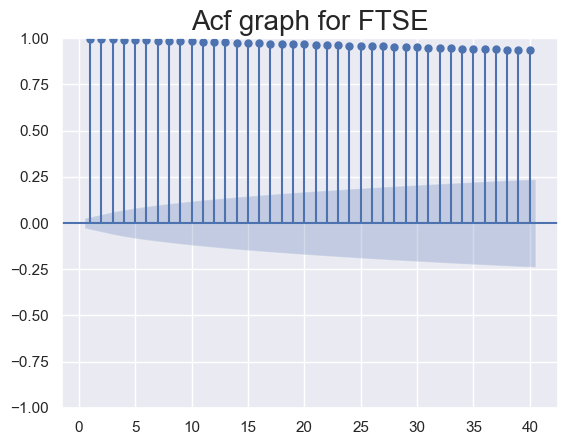

In [48]:
sgt.plot_acf(df.market_price, lags = 40, zero = False)
plt.title("Acf graph for FTSE", size=20)
plt.show()

Partial Auto-correlation (PACF)

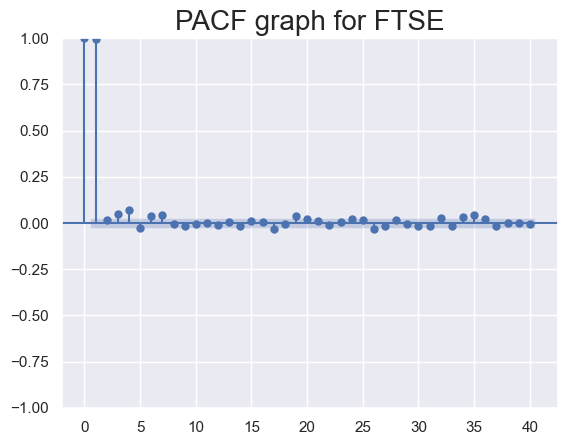

In [49]:
sgt.plot_pacf(df.market_price, lags=40, method="ols",)
plt.title("PACF graph for FTSE", size=20)
plt.show()